In [2]:
import scanpy as sc
import sys
sys.path.append('/Users/amossi/Documents/code')
import FISHspace as sp
from scipy.spatial import KDTree
import numpy as np
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

# make font changeable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2

# use colorblind seaborn style

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [ ]:
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
rename_dic = {
    'WR 5':'WR Endo.Ass.',
    'WR 2':'WR Periphery1',
    'WR 3':'WR Periphery2',
    'WR 1':'WR Periphery3',
    
    'WR 6':'WR HYPR1',
    'WR 8':'WR HYPR2',
    'WR 7':'WR OPC',
    'WR 4':'WR nIPC',
    
    'nIPC-RG-like':'RG-like',
    
 
}

adata.obs['m-states'] = pd.Categorical([rename_dic[m] if m in rename_dic else m for m in adata.obs['m-states']])

In [5]:
palette = {
    'AC-like 1':'#2ecc71',#inchworm B4FF9F
    'AC-like 2':'#2ecc71',#inchworm B4FF9F
    'AC-like 3':'#2ecc71',#inchworm B4FF9F
    'AC-like 4':'#2ecc71',#inchworm B4FF9F
    'AC-like 5':'#2ecc71',#inchworm B4FF9F
    'AC-like 6':'#2ecc71',#inchworm B4FF9F
    'AC-like 7':'#2ecc71',#inchworm B4FF9F

    'preOPC-like':'#7befb2',#'#c2f970'
    
    'GBL-like 1':'#c2f970',
    'GBL-like 2':'#c2f970',

    'WR Endo.Ass.':'#e76d89',# Deep cerise
    'WR Periphery1':'#e76d89',# Deep cerise
    'WR Periphery2':'#e76d89',# Deep cerise
    'WR Periphery3':'#e76d89',# Deep cerise
    'WR HYPR1':'#e76d89',# Deep cerise
    'WR HYPR2':'#e76d89',# Deep cerise
    'WR nIPC':'#e76d89',# Deep cerise
    'WR OPC':'#e76d89',# Deep cerise
    
    'RG-like':'#ff9470',
    'nIPC-RG-like':'#ff9470',
    
    'OPC-like 1':'#89c4f4', #bright turquoise
    'OPC-like 2':'#89c4f4', #bright turquoise
    
    'TAM-BDM 1':'#e3ba8f', #wood
    'TAM-BDM 2':'#e3ba8f',
    'TAM-BDM 3':'#e3ba8f',
    'TAM-BDM 4':'#e3ba8f', #wood

    'TAM-MG':'#a6915c',#red orange
    'Mono 1': '#f4ede4',
    'Mono 2': '#f4ede4',
    
    'Oligodendrocyte':'#392e4a',
    'Astrocyte':'#038aff',
    
    'Endothelial':'#d5b8ff', # '#d5b8ff',  

    'Mural cell 1': '#8c14fc',  #electric indigo
    'Mural cell 2': '#8c14fc',  #electric indigo

    'FB-like 2': '#9f5afd', #fff9de
    'FB-like 3': '#9f5afd', #fff9de

}

INFO:root:First filter, 180933 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 7820 cells left


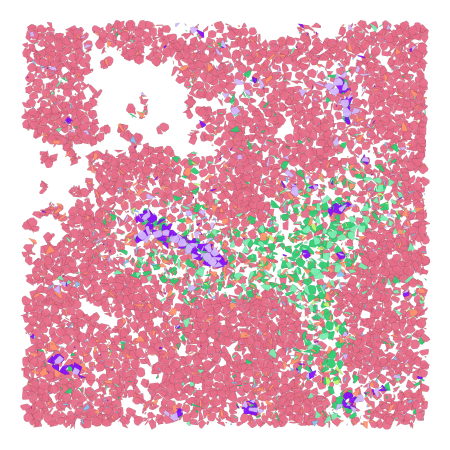

In [6]:
sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    palette=palette,
    cluster_key= 'm-states',
    clusters = ['WR HYPR1', 'WR HYPR2', 'AC-like 3','GBL-like 2', 'RG-like', 'OPC-like 1', 'OPC-like 2', 'preOPC-like', 'Mural cell 1', 'Mural cell 2','Endothelial'],
    
    xlim = (11000, 13000),
    ylim= (5000, 7000),
    figsize=(5,5),
    dpi=300,
    alpha=.95,
    show_scalebar=False,
    
    save=True,
    savepath='figures/SL035B_zoom.svg',
    
)

INFO:root:First filter, 124430 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 25654 cells left


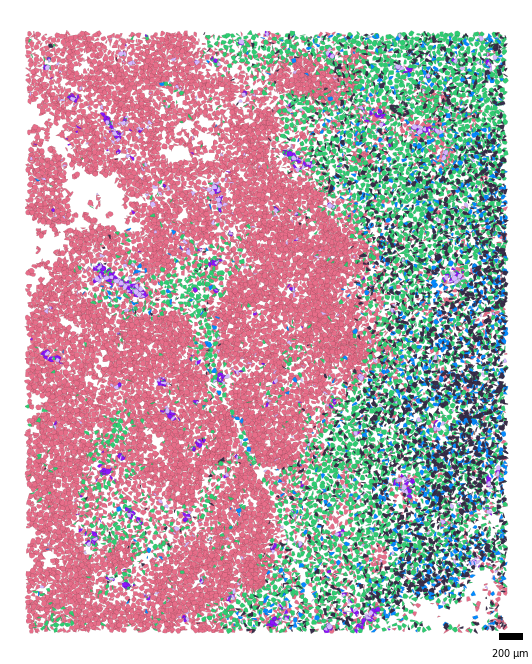

In [8]:
sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    palette=palette,
    cluster_key= 'm-states',
    clusters = ['WR HYPR1', 'WR HYPR2', 'AC-like 3','Mural cell 1','Mural cell 2','Endothelial', 'Astrocyte', 'Oligodendrocyte'],
    grey_clusters = ['MES-like'],
    xlim = (11000, 15000),
    ylim= (3000, 8000),
    figsize=(6,7),
    dpi=300,
    area_min_size=150,
    alpha=1,
    show_scalebar=True,
    #save=True,
    #savepath='figures/SL035B_border.svg',
)

INFO:root:First filter, 146625 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 17746 cells left


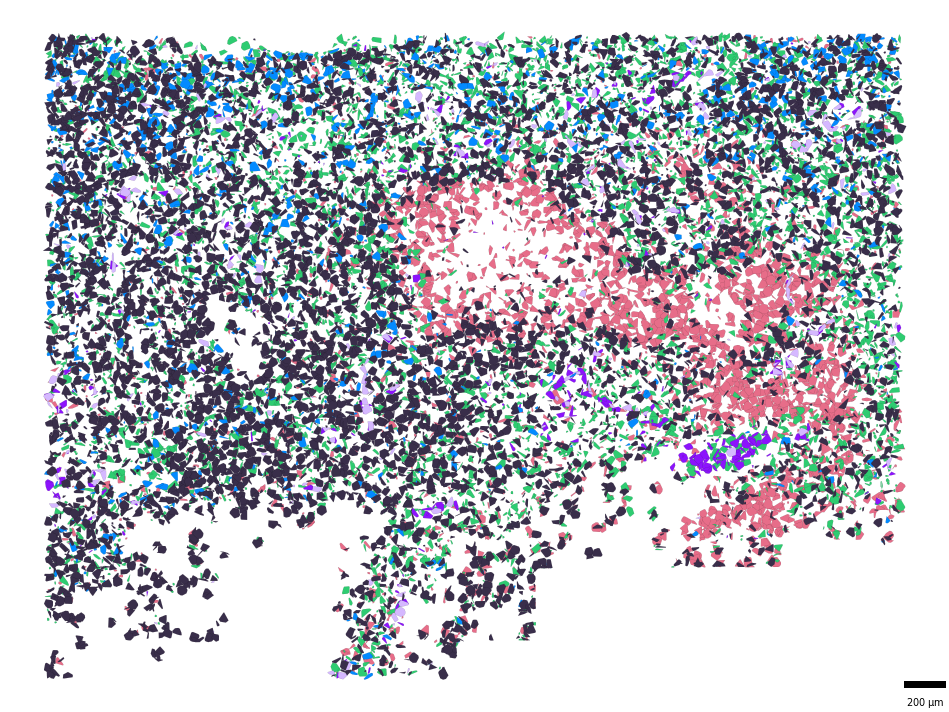

In [10]:
sp.pl.plot_polygons(
    adata,
    sample='SL046C',
    cluster_key='m-states',
    clusters = ['WR HYPR1', 'WR HYPR2', 'AC-like 1', 'AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 7','Mural cell 1','Mural cell 2','Endothelial', 'Astrocyte', 'Oligodendrocyte'],
    #grey_clusters= adata.obs['m-states'].cat.categories.tolist(),
    #alpha_gray=.9,
    xlim=(6000,10000),
    ylim=(1000,4000),

    show_axis=False,
    palette=palette,
    figsize=(10,10),
    alpha=1,
    #facecolor=(0,0,0),

    area_min_size=50,
    fontsize=12,
    annotation_rotation=-90,
    annotation_text_offset=(50,-300),
    save=True,
    savepath='figures/SL046C_zoom.svg',   
)

INFO:root:First filter, 117355 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 6048 cells left


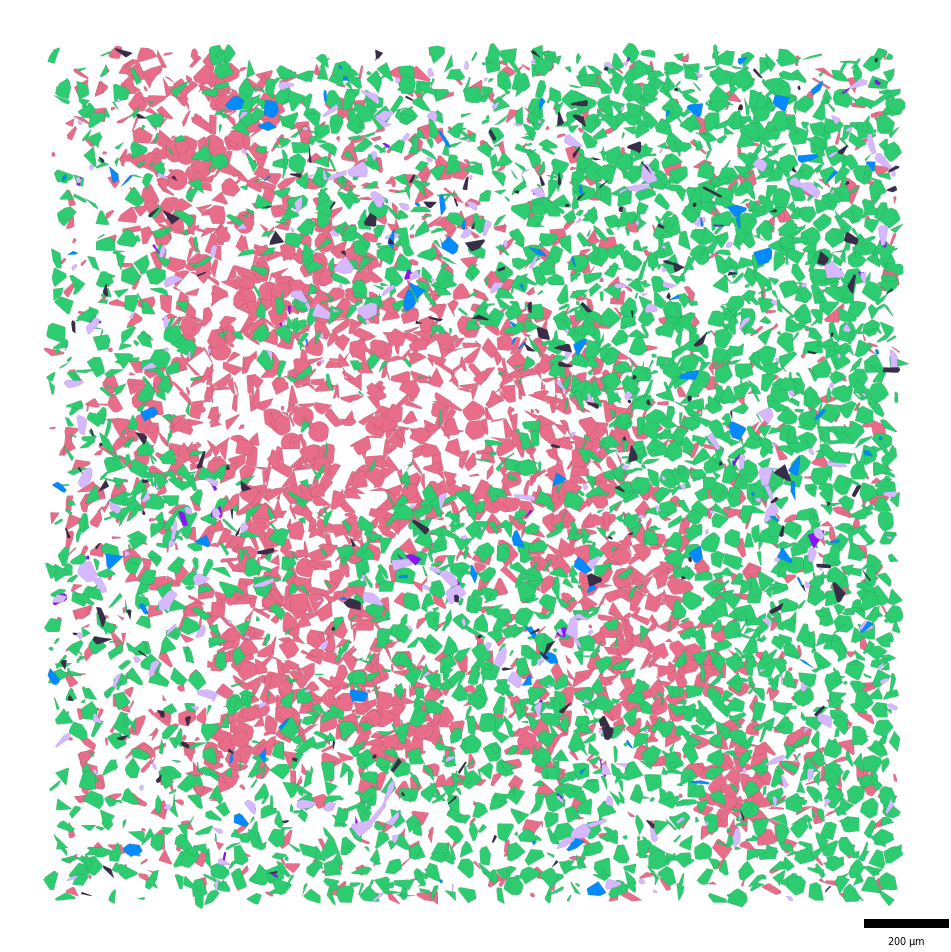

In [11]:
sp.pl.plot_polygons(
    adata,
    sample='SL061B',
    cluster_key='m-states',
    clusters = ['WR HYPR1', 'WR HYPR2', 'AC-like 1', 'AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 7','Mural cell 1','Mural cell 2','Endothelial', 'Astrocyte', 'Oligodendrocyte'],
    #grey_clusters= adata.obs['m-states'].cat.categories.tolist(),
    #alpha_gray=.9,
    xlim = (4000,6000),
    ylim = (4000,6000),
    show_axis=False,
    palette=palette,
    figsize=(10,10),
    alpha=1,
    #facecolor=(0,0,0),

    area_min_size=50,
    fontsize=12,
    annotation_rotation=-90,
    annotation_text_offset=(50,-300),
    save=True,
    savepath='figures/SL061B_zoom.svg',   
)

INFO:root:First filter, 59224 cells left
INFO:root:Zoom filter, 59224 cells left


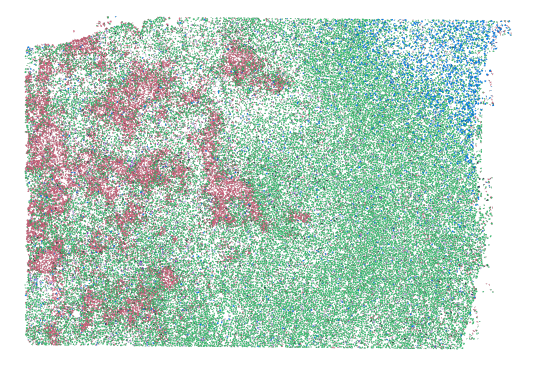

In [29]:
sp.pl.plot_polygons(
    adata,
    sample='SL061B',
    palette=palette,
    cluster_key= 'm-states',
    clusters = ['WR HYPR1', 'WR HYPR2', 'AC-like 3','Mural cell 1','Mural cell 2','Endothelial', 'Astrocyte', 'Oligodendrocyte'],
    grey_clusters = ['MES-like'],
    #xlim = (11000, 15000),
    #ylim= (3000, 8000),
    figsize=(6,6),
    dpi=300,
    area_min_size=150,
    alpha=1,

    show_scalebar=False,
    
    save=True,
    savepath='figures/SL061B_border.svg',
)

INFO:root:First filter, 98298 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2266 cells left


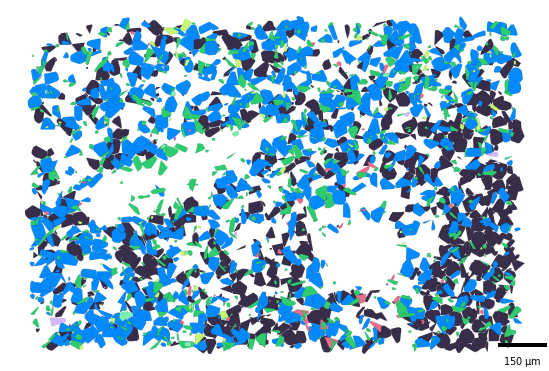

In [12]:
sp.pl.plot_polygons(
    adata,
    sample='SL001B',
    palette=palette,
    cluster_key= 'm-states',
    clusters = [ 'Oligodendrocyte','Astrocyte','Mural cell 1','Mural cell 2','Endothelial','WR HYPR1', 'WR HYPR2', 'AC-like 1', 'AC-like 2','AC-like 3','AC-like 4','AC-like 5','AC-like 6','AC-like 7', 'GBL-like 1', 'preOPC-like'],
    
    xlim=(3500,5000),
    ylim=(1800,2800),
    figsize=(6,6),
    dpi=300,
    #area_min_size=150,
    alpha=1,

    show_scalebar=True,
    
    save=True,
    savepath='figures/SL001B_zoom.svg',
)

INFO:root:First filter, 124772 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 24390 cells left


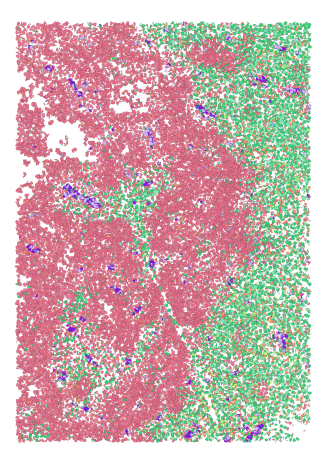

In [37]:
sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    palette=palette,
    cluster_key= 'm-states',
    clusters = ['WR HYPR1', 'WR HYPR2', 'AC-like 3','GBL-like 2', 'RG-like', 'OPC-like 1', 'OPC-like 2', 'preOPC-like', 'Mural cell 1','Mural cell 2','Endothelial'],
    grey_clusters = ['MES-like'],
    xlim = (11000, 14500),
    ylim= (3000, 8000),
    figsize=(5,5),
    dpi=300,
    area_min_size=150,
    alpha=.95,
    show_scalebar=False,
    
    save=True,
    savepath='figures/SL035B_border.svg',
)